In [1]:
#Load Feature Dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/time_window_features.csv")
df.head()

,TransactionDT,TransactionAmt,customer_id,card1,card2,ProductCD,isFraud,txn_count_1h,txn_count_24h,txn_count_7d,avg_amt_1h,avg_amt_24h,avg_amt_7d,max_amt_24h,amount_dev_24h,std_amt_24h,amount_zscore_24h,hour,is_night_txn
0,1970-04-10 22:40:15,19.093,10003_555.0,10003,555.0,C,0,2.0,2.0,3.0,14.924,14.924000,23.080667,19.093,4.169000,5.895856,0.707107,22,0
1,1970-04-11 00:40:05,19.093,10003_555.0,10003,555.0,C,0,1.0,3.0,4.0,19.093,16.313667,22.083750,19.093,2.779333,4.813947,0.577350,0,1
2,1970-01-16 18:25:07,100.000,10004_529.0,10004,529.0,R,0,1.0,2.0,2.0,100.000,125.000000,125.000000,150.000,-25.000000,35.355339,-0.707107,18,0
3,1970-02-13 19:58:39,107.950,10004_529.0,10004,529.0,W,0,1.0,2.0,3.0,107.950,316.450000,736.133333,524.950,-208.500000,294.863528,-0.707107,19,0
4,1970-02-16 09:20:45,54.490,10004_529.0,10004,529.0,W,0,1.0,2.0,4.0,54.490,42.745000,179.597500,54.490,11.745000,16.609938,0.707107,9,0


In [2]:
df["velocity_risk"] = (
    df["txn_count_1h"] / (df["txn_count_24h"] + 1)
).clip(0, 1)


In [3]:
df[["txn_count_1h", "txn_count_24h", "velocity_risk"]].describe()


,txn_count_1h,txn_count_24h,velocity_risk
count,441762.000000,441762.000000,441762.000000
mean,2.892297,25.773548,0.186144
std,6.285429,51.232329,0.139735
min,1.000000,2.000000,0.001157
25%,1.000000,4.000000,0.083333
50%,2.000000,11.000000,0.142857
75%,3.000000,27.000000,0.250000
max,192.000000,881.000000,0.981132


In [4]:
#Separate Fraud vs Non-Fraud
fraud = df[df["isFraud"] == 1]
non_fraud = df[df["isFraud"] == 0]

print("Fraud count:", len(fraud))
print("Non-fraud count:", len(non_fraud))


Fraud count: 16261
Non-fraud count: 425501


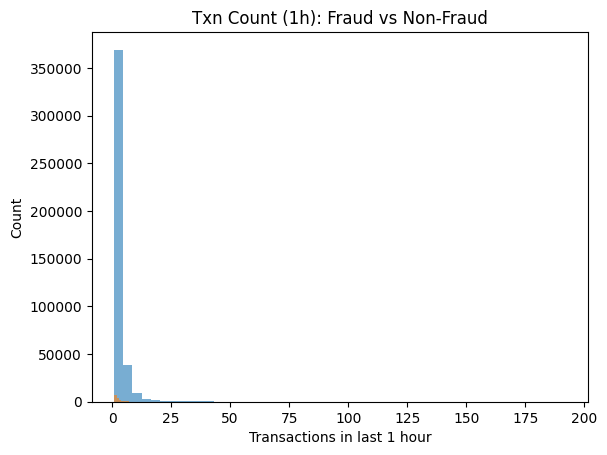

In [5]:
#Transaction Velocity vs Fraud
#Transactions in last 1 hour
plt.figure()
plt.hist(non_fraud["txn_count_1h"], bins=50, alpha=0.6)
plt.hist(fraud["txn_count_1h"], bins=50, alpha=0.6)
plt.xlabel("Transactions in last 1 hour")
plt.ylabel("Count")
plt.title("Txn Count (1h): Fraud vs Non-Fraud")
plt.show()


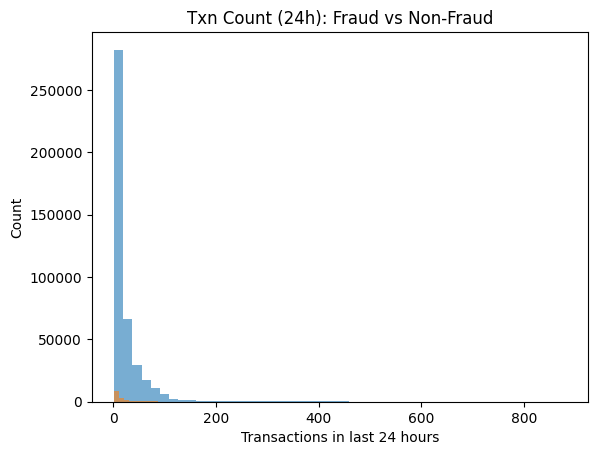

In [6]:
#24-Hour Velocity Comparison
plt.figure()
plt.hist(non_fraud["txn_count_24h"], bins=50, alpha=0.6)
plt.hist(fraud["txn_count_24h"], bins=50, alpha=0.6)
plt.xlabel("Transactions in last 24 hours")
plt.ylabel("Count")
plt.title("Txn Count (24h): Fraud vs Non-Fraud")
plt.show()


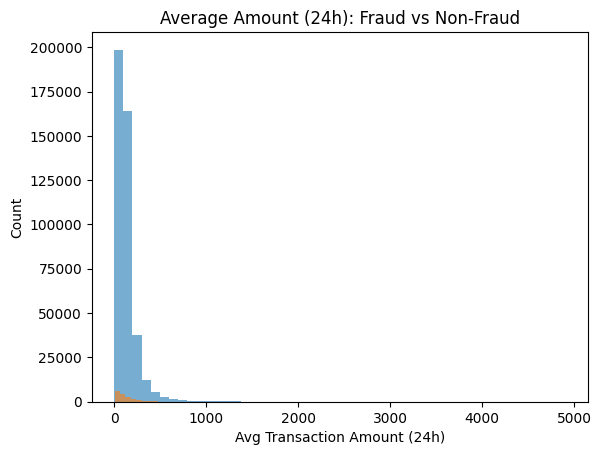

In [7]:
#Spending Behavior (Average Amount)
plt.figure()
plt.hist(non_fraud["avg_amt_24h"], bins=50, alpha=0.6)
plt.hist(fraud["avg_amt_24h"], bins=50, alpha=0.6)
plt.xlabel("Avg Transaction Amount (24h)")
plt.ylabel("Count")
plt.title("Average Amount (24h): Fraud vs Non-Fraud")
plt.show()


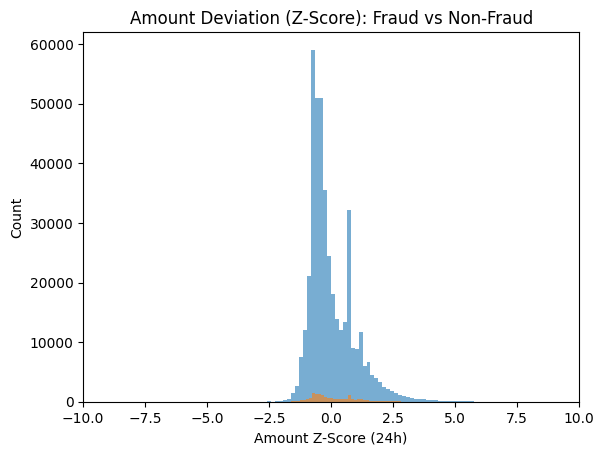

In [8]:
#Amount Deviation
#Z-Score Distribution
plt.figure()
plt.hist(non_fraud["amount_zscore_24h"], bins=100, alpha=0.6)
plt.hist(fraud["amount_zscore_24h"], bins=100, alpha=0.6)
plt.xlim(-10, 10)
plt.xlabel("Amount Z-Score (24h)")
plt.ylabel("Count")
plt.title("Amount Deviation (Z-Score): Fraud vs Non-Fraud")
plt.show()


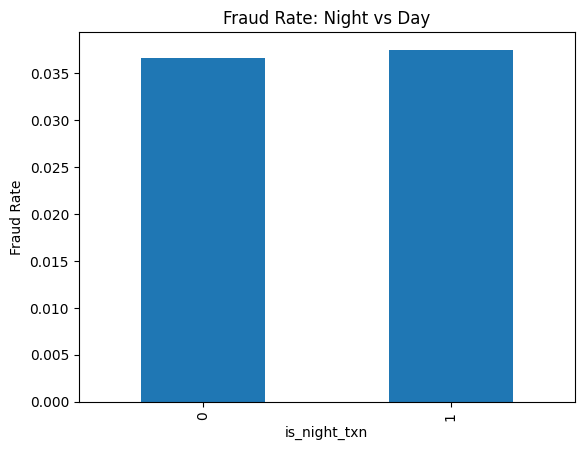

In [9]:
#Night-Time Transactions
night_fraud_rate = (
    df.groupby("is_night_txn")["isFraud"].mean()
)

night_fraud_rate.plot(kind="bar", title="Fraud Rate: Night vs Day")
plt.ylabel("Fraud Rate")
plt.show()


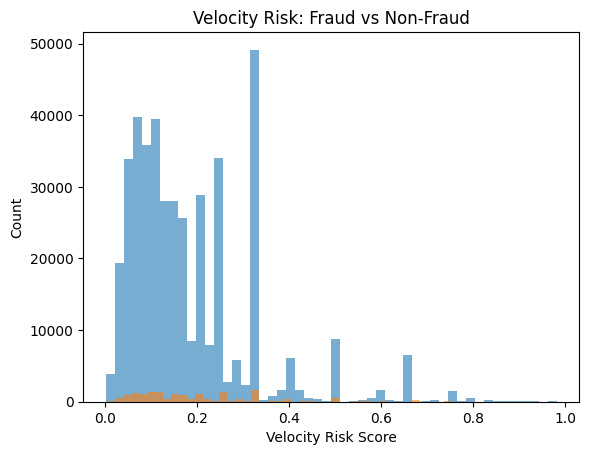

In [10]:
#Combined Risk Visualization
df["velocity_risk"] = (
    df["txn_count_1h"] / df["txn_count_24h"]
)

plt.figure()
plt.hist(non_fraud["velocity_risk"], bins=50, alpha=0.6)
plt.hist(fraud["velocity_risk"], bins=50, alpha=0.6)
plt.xlabel("Velocity Risk Score")
plt.ylabel("Count")
plt.title("Velocity Risk: Fraud vs Non-Fraud")

plt.savefig("../reports/velocity_vs_fraud.png", dpi=150, bbox_inches="tight")
plt.show()



In [11]:
plt.savefig("../reports/velocity_vs_fraud.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>